In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'
import sys
sys.path.append("/mnt/y/code/250513_metabolic_process_models")
import jax 
import jax.numpy as jnp
import equinox as eqx
import importlib
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import numpy as np
import sympy as sp

import MPMs.MPM_functions_07 as MF
import MPMs.DATA_functions_01 as DF
import MPMs.UTIL_functions_01 as UF
importlib.reload(UF)
importlib.reload(DF)
importlib.reload(MF);

In [2]:
import numpy as np
from PIL import Image, ImageOps
def trim_whitespace(path,padding=0):
    # Code from
    # https://gist.github.com/thomastweets/c7680e41ed88452d3c63401bb35116ed
    padding = np.array([-1*padding, -1*padding, padding, padding])
    image=Image.open(path)
    image.load()
    imageSize = image.size
    # remove alpha channel
    invert_im = image.convert("RGB")
    # invert image (so that white is 0)
    invert_im = ImageOps.invert(invert_im)
    imageBox = invert_im.getbbox()
    imageBox = tuple(np.asarray(imageBox)+padding)
    cropped=image.crop(imageBox)
    print("Size:", imageSize, "New Size:", imageBox)
    cropped.save(path)

def save_trim_push(path,name,padding=0,trim=True,subfolder="figures",dpi=None):
    # By default I save all my figures in a subfolder called "figures".
    # Make sure this subfolder exists before you exectue this function.
    full_path = os.path.join(path,subfolder,name)
    if dpi is None:
        dpi = plt.gcf().get_dpi()
    plt.savefig(full_path,dpi=dpi)
    if trim:
        trim_whitespace(full_path,padding)
    push2overleaf(path,name)
    return

import os
def push2overleaf(path, comment):
    # get current pwd
    tmp_pwd = os.getcwd()
    # change pwd to git repo
    os.chdir(path)
    # do git commands
    os.system("git pull")
    os.system("git add .")
    os.system('git commit -m "' + comment + '"')
    os.system("git push")
    # change pwd back
    os.chdir(tmp_pwd)
    return

git_path = "/home/mgotsmy/overleaf/688f5daf4e30e6d98498e7b8/"

# Load Symbolic Regression Model

In [3]:
model_path = "/mnt/y/code/250513_metabolic_process_models/slim_fba_data/02_run_SR_on_FBA.py"
MM = UF.import_module_from_path(model_path)
importlib.reload(MM)

COL_inp, COL_out = MM.get_columns_inp_out()


# --- LOAD DATA --- #
X, Y = MM.get_FBA_data(COL_inp, COL_out)

# --- GET SCALERS --- #
SCLs = MM.get_scalers(COL_inp, COL_out)

# --- PREPROCESS DATA --- #
train_, valid_ = MM.split_scale(X,Y,SCLs)
print(train_[0].shape, train_[1].shape, valid_[0].shape, valid_[1].shape)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
(9000, 4) (9000, 8) (1000, 4) (1000, 8)


In [4]:
import pysr
model = pysr.PySRRegressor.from_file(run_directory=f"./sr_models/run_SR_on_FBA_03")

x_data, y_data = valid_
y_pred = model.predict(x_data)
Y_data = SCLs[1].unscale(y_data)
Y_pred = SCLs[1].unscale(y_pred)

Attempting to load model from sr_models/run_SR_on_FBA_03/checkpoint.pkl...


Lowest 100% of the data
name                              tmp_r2   tmp_mae
EX_glc__D_e                       1.0000    0.0000
pDNA_synthesis                    0.9794    0.0013
BIOMASS_Ec_iML1515_core_75p37M    0.9999    0.0025
ATPM                              0.9995    1.4543
EX_co2_e                          0.9998    0.2847
EX_nh4_e                          0.9991    0.1034
EX_o2_e                           0.9998    0.2616
EX_so4_e                          0.9999    0.0006


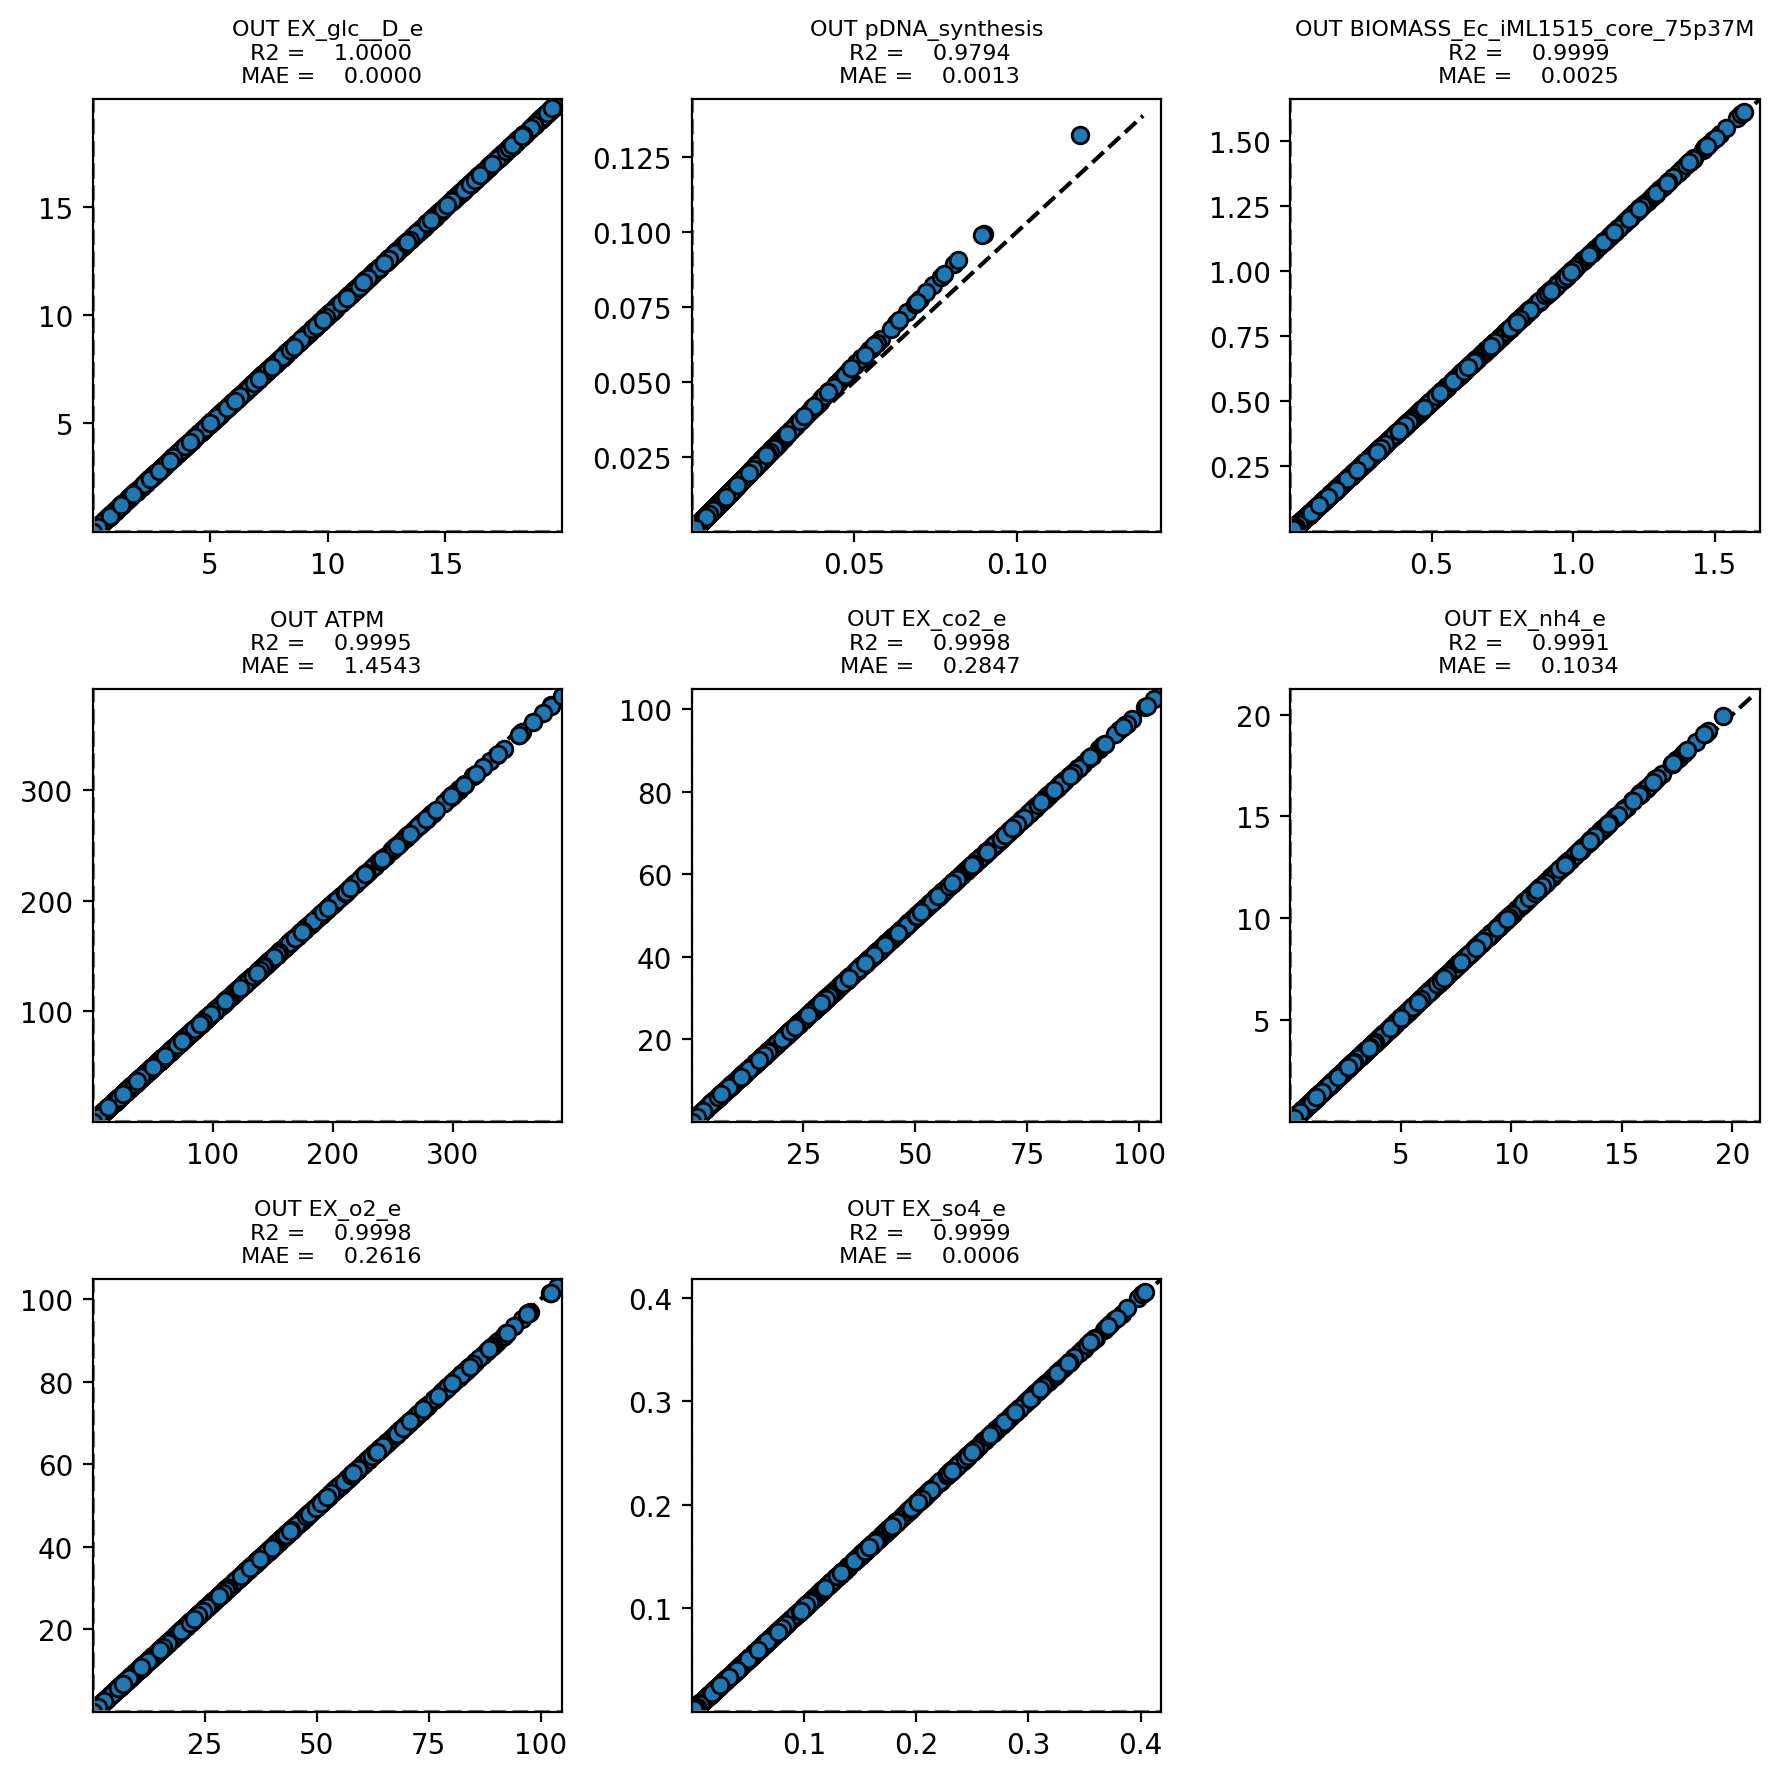

In [9]:
# Y_data = valid_[1]
# Y_pred = y_pred

lowest_n_percent = 100
# lowest_n_percent = 5
n = 0
n_cols = 3
# COL_out = ['BIOMASS_Ec_iJO1366_core_53p95M']
n_rows = (len(COL_out))//n_cols+1
plt.figure(dpi=200,figsize=(n_cols*3,n_rows*3))

print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")
for i, name in enumerate(COL_out):
    # find the lowest_n_percent of the data
    _max = Y_data[:,i].max()
    _min = Y_data[:,i].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = Y_pred[:,i] <= _new_max


    n += 1
    ax = plt.subplot(n_rows,n_cols,n)
    tmp_r2 = UF.R2(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    tmp_mae= UF.MAE(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    print(f"{name:30} {tmp_r2:9.4f} {tmp_mae:9.4f}")
    plt.title(f"OUT {name}\n R2 = {tmp_r2:9.4f}\n MAE = {tmp_mae:9.4f}",fontsize=8)
    plt.scatter(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i],edgecolor="k")
    UF.diag(ax)
    ax.axhline(0,color="grey",linestyle="--")
    ax.axvline(0,color="grey",linestyle="--")
    ax.set_xlim(_min,_new_max)
    ax.set_ylim(_min,_new_max)
plt.tight_layout()
plt.show()

# Scipy -- Fit generalized Equation

In [5]:
x_data, y_data = train_

In [14]:
import scipy

def get_qN_multi(x_data,denominator,Y):
    numerator = get_denominator(x_data,Y[0],Y[1],Y[2])
    qN = x_data[:,0]*numerator/denominator
    return qN

def get_qN(x_data,denominator,yN,N):
    qN = x_data[:,0]*x_data[:,N]*yN/denominator
    return qN

def get_denominator(x_data,y1,y2,y3):
    return x_data[:,1] * y1 + x_data[:,2] * y2 + x_data[:,3] * y3

def get_L_qN(qN_pred,qN_data):
    # return np.mean(np.abs(qN_pred - qN_data))
    return UF.NMAE(qN_data,qN_pred)

def fun(theta,*args):
    global i
    i += 1

    x_data, y_data = args
    y1, y2, y3 = theta[:3]
    yX, yP, yM = theta[3:6]
    Y1 = theta[6:9]
    Y2 = theta[9:12]
    Y3 = theta[12:15]
    Y4 = theta[15:18]
    D1 = theta[18:21]
    D2 = theta[21:24]
    D3 = theta[24:27]
    D4 = theta[27:30]


    denominator = get_denominator(x_data, y1,y2,y3)

    qX_pred = get_qN(x_data, denominator, yX, 1)
    L_qX = get_L_qN(qX_pred,y_data[:,2])#/SCLs[1].avg[2]

    qP_pred = get_qN(x_data, denominator, yP, 2)
    L_qP = get_L_qN(qP_pred,y_data[:,1])#/SCLs[1].avg[1]

    qM_pred = get_qN(x_data, denominator, yM, 3)
    L_qM = get_L_qN(qM_pred,y_data[:,3])#/SCLs[1].avg[3]


    q1_pred = get_qN_multi(x_data, get_denominator(x_data,*D1), Y1)
    L_q1 = get_L_qN(q1_pred,y_data[:,4])#/SCLs[1].avg[4]

    q2_pred = get_qN_multi(x_data, get_denominator(x_data,*D2), Y2)
    L_q2 = get_L_qN(q2_pred,y_data[:,5])#/SCLs[1].avg[5]

    q3_pred = get_qN_multi(x_data, get_denominator(x_data,*D3), Y3)
    L_q3 = get_L_qN(q3_pred,y_data[:,6])#/SCLs[1].avg[6]

    q4_pred = get_qN_multi(x_data, get_denominator(x_data,*D4), Y4)
    L_q4 = get_L_qN(q4_pred,y_data[:,7])#/SCLs[1].avg[7]
    
    if i%100==0 or i == 1:
        # print(i, L_qX, L_qP, L_qM, L_q1, L_q2, L_q3, L_q4)
        print(f"{i:5} | {L_qX:6.3e} | {L_qP:6.3e} | {L_qM:6.3e} | {L_q1:6.3e} | {L_q2:6.3e} | {L_q3:6.3e} | {L_q4:6.3e}")
    return L_qX + L_qP + L_qM + L_q1 + L_q2 + L_q3 + L_q4
    # return L_qX+L_qP+L_qM
    # return L_q4

i = 0
args = (x_data,y_data)
theta0 = np.ones(30)
# qX, qP, qM
theta0[0:6] = np.array([1.10950079, 0.0628479 , 0.85681643, 2.10724057, 1.74809832, 1.95996956])

# qCO2
theta0[6:9] = np.array([1.19809109, 0.03027642, 2.42966269])
theta0[18:21] = np.array([2.02888031, 0.11516565, 1.56248065])

# qNH4
theta0[9:12] = np.array([ 1.96340144e+00,  2.18087868e-01, -7.04542343e-04])
theta0[21:24] = np.array([1.1732349 , 0.06647372, 0.9034785 ])

# qO2
theta0[12:15] = np.array([0.94682931, 0.04596531, 2.09859217])
theta0[24:27] = np.array([1.7184889 , 0.09761909, 1.32359045])

# qSO4
theta0[15:18] = np.array([ 5.90899249e+00,  5.01415977e-04, -1.54926636e-03])
theta0[27:30] = np.array([3.11344575, 0.17703523, 2.39876119])

_ = scipy.optimize.minimize(fun, x0=theta0, args=args, method='Nelder-Mead',
                            options={"fatol":1e-8,"xatol":1e-8})
# _ = scipy.optimize.minimize(fun, x0=np.ones(30), args=args, method='COBYLA',options={"tol":1e-16})#,options={"fatol":1e-16,"xatol":1e-16})
print("done")
print(_.message)

    1 | 5.577e-03 | 1.081e-01 | 1.477e-02 | 7.720e-03 | 1.743e-02 | 7.229e-03 | 5.340e-03
  100 | 2.874e-03 | 6.574e-02 | 1.295e-02 | 3.085e-03 | 1.110e-03 | 3.463e-02 | 2.889e-03
  200 | 1.493e-03 | 1.024e-02 | 8.789e-03 | 2.168e-03 | 4.332e-03 | 2.602e-03 | 1.380e-03
  300 | 1.340e-03 | 3.506e-03 | 7.688e-03 | 9.647e-04 | 9.008e-04 | 1.822e-03 | 1.553e-03
  400 | 1.638e-03 | 1.794e-03 | 3.414e-03 | 7.399e-04 | 1.294e-03 | 1.666e-03 | 1.571e-03
  500 | 2.617e-03 | 5.816e-04 | 3.735e-04 | 1.222e-03 | 1.517e-03 | 1.629e-03 | 1.418e-03
  600 | 7.172e-04 | 1.273e-03 | 7.135e-04 | 8.445e-04 | 1.666e-03 | 1.299e-03 | 1.499e-03
  700 | 7.805e-04 | 7.971e-04 | 7.240e-04 | 8.898e-04 | 1.073e-03 | 9.132e-04 | 1.590e-03
  800 | 7.122e-04 | 6.512e-04 | 6.238e-04 | 8.118e-04 | 1.159e-03 | 5.877e-04 | 1.352e-03
  900 | 6.552e-04 | 7.780e-04 | 3.774e-04 | 6.177e-04 | 9.126e-04 | 4.312e-04 | 1.272e-03
 1000 | 6.128e-04 | 5.335e-04 | 2.424e-04 | 6.450e-04 | 7.980e-04 | 4.426e-04 | 1.238e-03
 1100 | 5.

KeyboardInterrupt: 

In [13]:
x_data, y_data = args
theta = _.x

y1, y2, y3 = theta[:3]
yX, yP, yM = theta[3:6]
Y1 = theta[6:9]
Y2 = theta[9:12]
Y3 = theta[12:15]
Y4 = theta[15:18]
D1 = theta[18:21]
D2 = theta[21:24]
D3 = theta[24:27]
D4 = theta[27:30]


denominator = get_denominator(x_data, y1,y2,y3)
lowest_n_percent = 100
lowest_n_percent = 5
print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_nmae':>9}")

n_cols = 3
n_rows = (len(COL_out))//n_cols+1
plt.figure(dpi=200,figsize=(n_cols*3,n_rows*3))

# plot qX, qP, qM
for LOC_inp, LOC_out in zip([1,2,3],[2,1,3]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    ax = plt.subplot(n_rows,n_cols,LOC_inp)
    ax.set_title(name)
    
    _max = y_data[:,LOC_out].max()
    _min = y_data[:,LOC_out].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = y_data[:,LOC_out] <= _new_max

    
    
    q_pred = get_qN(x_data, denominator, theta[LOC_inp+2], LOC_inp)
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    tmp_r2 = UF.R2( y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    tmp_mae= UF.NMAE(y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    print(f"{name:30} {tmp_r2:9.5f} {tmp_mae:9.5f}")


    plt.scatter( q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out],edgecolors="k")
    UF.diag(ax)

# plot qCO2, qNH4, qO2, qSO4
DD = [D1,D2,D3,D4]
YY = [Y1,Y2,Y3,Y4]
for j, LOC_out in enumerate([4,5,6,7]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    ax = plt.subplot(n_rows,n_cols,LOC_out)
    ax.set_title(name)

    _max = y_data[:,LOC_out].max()
    _min = y_data[:,LOC_out].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = y_data[:,LOC_out] <= _new_max
    
    q_pred = get_qN_multi(x_data, get_denominator(x_data,*DD[j]), YY[j])
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    tmp_r2 = UF.R2( y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    tmp_mae= UF.NMAE(y_data[_new_max_mask,LOC_out],q_pred[_new_max_mask])
    print(f"{name:30} {tmp_r2:9.5f} {tmp_mae:9.5f}")


    ax.scatter( q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out],edgecolors="k")
    UF.diag(ax)

plt.tight_layout()
plt.show()

AttributeError: 'Equality' object has no attribute 'x'

In [6]:
x_data, y_data = args
theta = _.x

y1, y2, y3 = theta[:3]
yX, yP, yM = theta[3:6]
Y1 = theta[6:9]
Y2 = theta[9:12]
Y3 = theta[12:15]
Y4 = theta[15:18]
D1 = theta[18:21]
D2 = theta[21:24]
D3 = theta[24:27]
D4 = theta[27:30]

flux_names = ["qG","qX","qP","qM","qCO2","qNH4","qO2","qSO4"]
denominator = get_denominator(x_data, y1,y2,y3)
for LOC_inp, LOC_out in zip([1,2,3],[2,1,3]):
    name = COL_out[LOC_out].replace("_Ec_iJO1366_core_53p95M","")
    
    q_pred = get_qN(x_data, denominator, theta[LOC_inp+2], LOC_inp)

    dem_str = ""
    yy = [y1,y2,y3]
    for j in [1,2,3]:
        dem_str += f"{yy[j-1]}*{COL_inp[j]} + "
    dem_str = dem_str[:-3]
    print(f"{flux_names[LOC_inp]} = qG * {theta[LOC_inp+2]}*{COL_inp[LOC_inp]} /({dem_str}) ".replace("nr","n"))

DD = [D1,D2,D3,D4]
YY = [Y1,Y2,Y3,Y4]
for j, LOC_out in enumerate([4,5,6,7]):
    
    q_pred = get_qN_multi(x_data, get_denominator(x_data,*DD[j]), YY[j])
    L = get_L_qN(q_pred[_new_max_mask],y_data[_new_max_mask,LOC_out])

    dem_str = ""
    num_str = ""
    for k in [1,2,3]:
        dem_str += f"{DD[j][k-1]}*{COL_inp[k]} + "
        num_str += f"{YY[j][k-1]}*{COL_inp[k]} + "
    dem_str = dem_str[:-3]
    num_str = num_str[:-3]
    print(f"{flux_names[LOC_out]} = qG * ({num_str}) /({dem_str}) ".replace("nr","n"))


qX = qG * 2.095925756666534*n_X /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
qP = qG * 1.5774883284049748*n_P /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
qM = qG * 1.9885886903097858*n_M /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
qCO2 = qG * (1.2082933347251283*n_X + 0.03140682552481298*n_P + 2.4389345018027253*n_M) /(2.0273005373419446*n_X + 0.11774348504170798*n_P + 1.5547353239688702*n_M) 
qNH4 = qG * (1.9515541853597302*n_X + 0.2147452343087246*n_P + -0.0007234803861126038*n_M) /(1.1874825647695029*n_X + 0.06552739969547203*n_P + 0.911539718451724*n_M) 
qO2 = qG * (0.9545539690035202*n_X + 0.047285966317114195*n_P + 2.0881011826979528*n_M) /(1.7127767420491968*n_X + 0.09842279611123259*n_P + 1.3054046578313026*n_M) 
qSO4 = qG * (5.876098016267782*n_X + 0.000509871455802084*n_P + -0.0015773984660723997*n_M) /(3.111874219100181*n_X + 0.1769442128559814*n_P + 2.3968877820508285*n_M) 


# Build Predictor Function

In [6]:
def general_predictor(x_data):
    qG = x_data[:,0]
    n_X = x_data[:,1]
    n_P = x_data[:,2]
    n_M = x_data[:,3]
    qX = qG * 2.095925756666534*n_X /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qP = qG * 1.5774883284049748*n_P /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qM = qG * 1.9885886903097858*n_M /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qCO2 = qG * (1.2082933347251283*n_X + 0.03140682552481298*n_P + 2.4389345018027253*n_M) /(2.0273005373419446*n_X + 0.11774348504170798*n_P + 1.5547353239688702*n_M) 
    qNH4 = qG * (1.9515541853597302*n_X + 0.2147452343087246*n_P + -0.0007234803861126038*n_M) /(1.1874825647695029*n_X + 0.06552739969547203*n_P + 0.911539718451724*n_M) 
    qO2 = qG * (0.9545539690035202*n_X + 0.047285966317114195*n_P + 2.0881011826979528*n_M) /(1.7127767420491968*n_X + 0.09842279611123259*n_P + 1.3054046578313026*n_M) 
    qSO4 = qG * (5.876098016267782*n_X + 0.000509871455802084*n_P + -0.0015773984660723997*n_M) /(3.111874219100181*n_X + 0.1769442128559814*n_P + 2.3968877820508285*n_M)
    return jnp.stack([qG,qP,qX,qM,qCO2,qNH4,qO2,qSO4],axis=1)

In [7]:
y_pred = general_predictor(x_data)

Lowest 5% of the data
name                              tmp_r2   tmp_mae
EX_glc__D_e                       1.0000    0.0000
pDNA_synthesis                    1.0000    0.0000
BIOMASS_Ec_iML1515_core_75p37M    1.0000    0.0000
ATPM                              1.0000    0.0111
EX_co2_e                          1.0000    0.0023
EX_nh4_e                          1.0000    0.0008
EX_o2_e                           1.0000    0.0016
EX_so4_e                          1.0000    0.0000


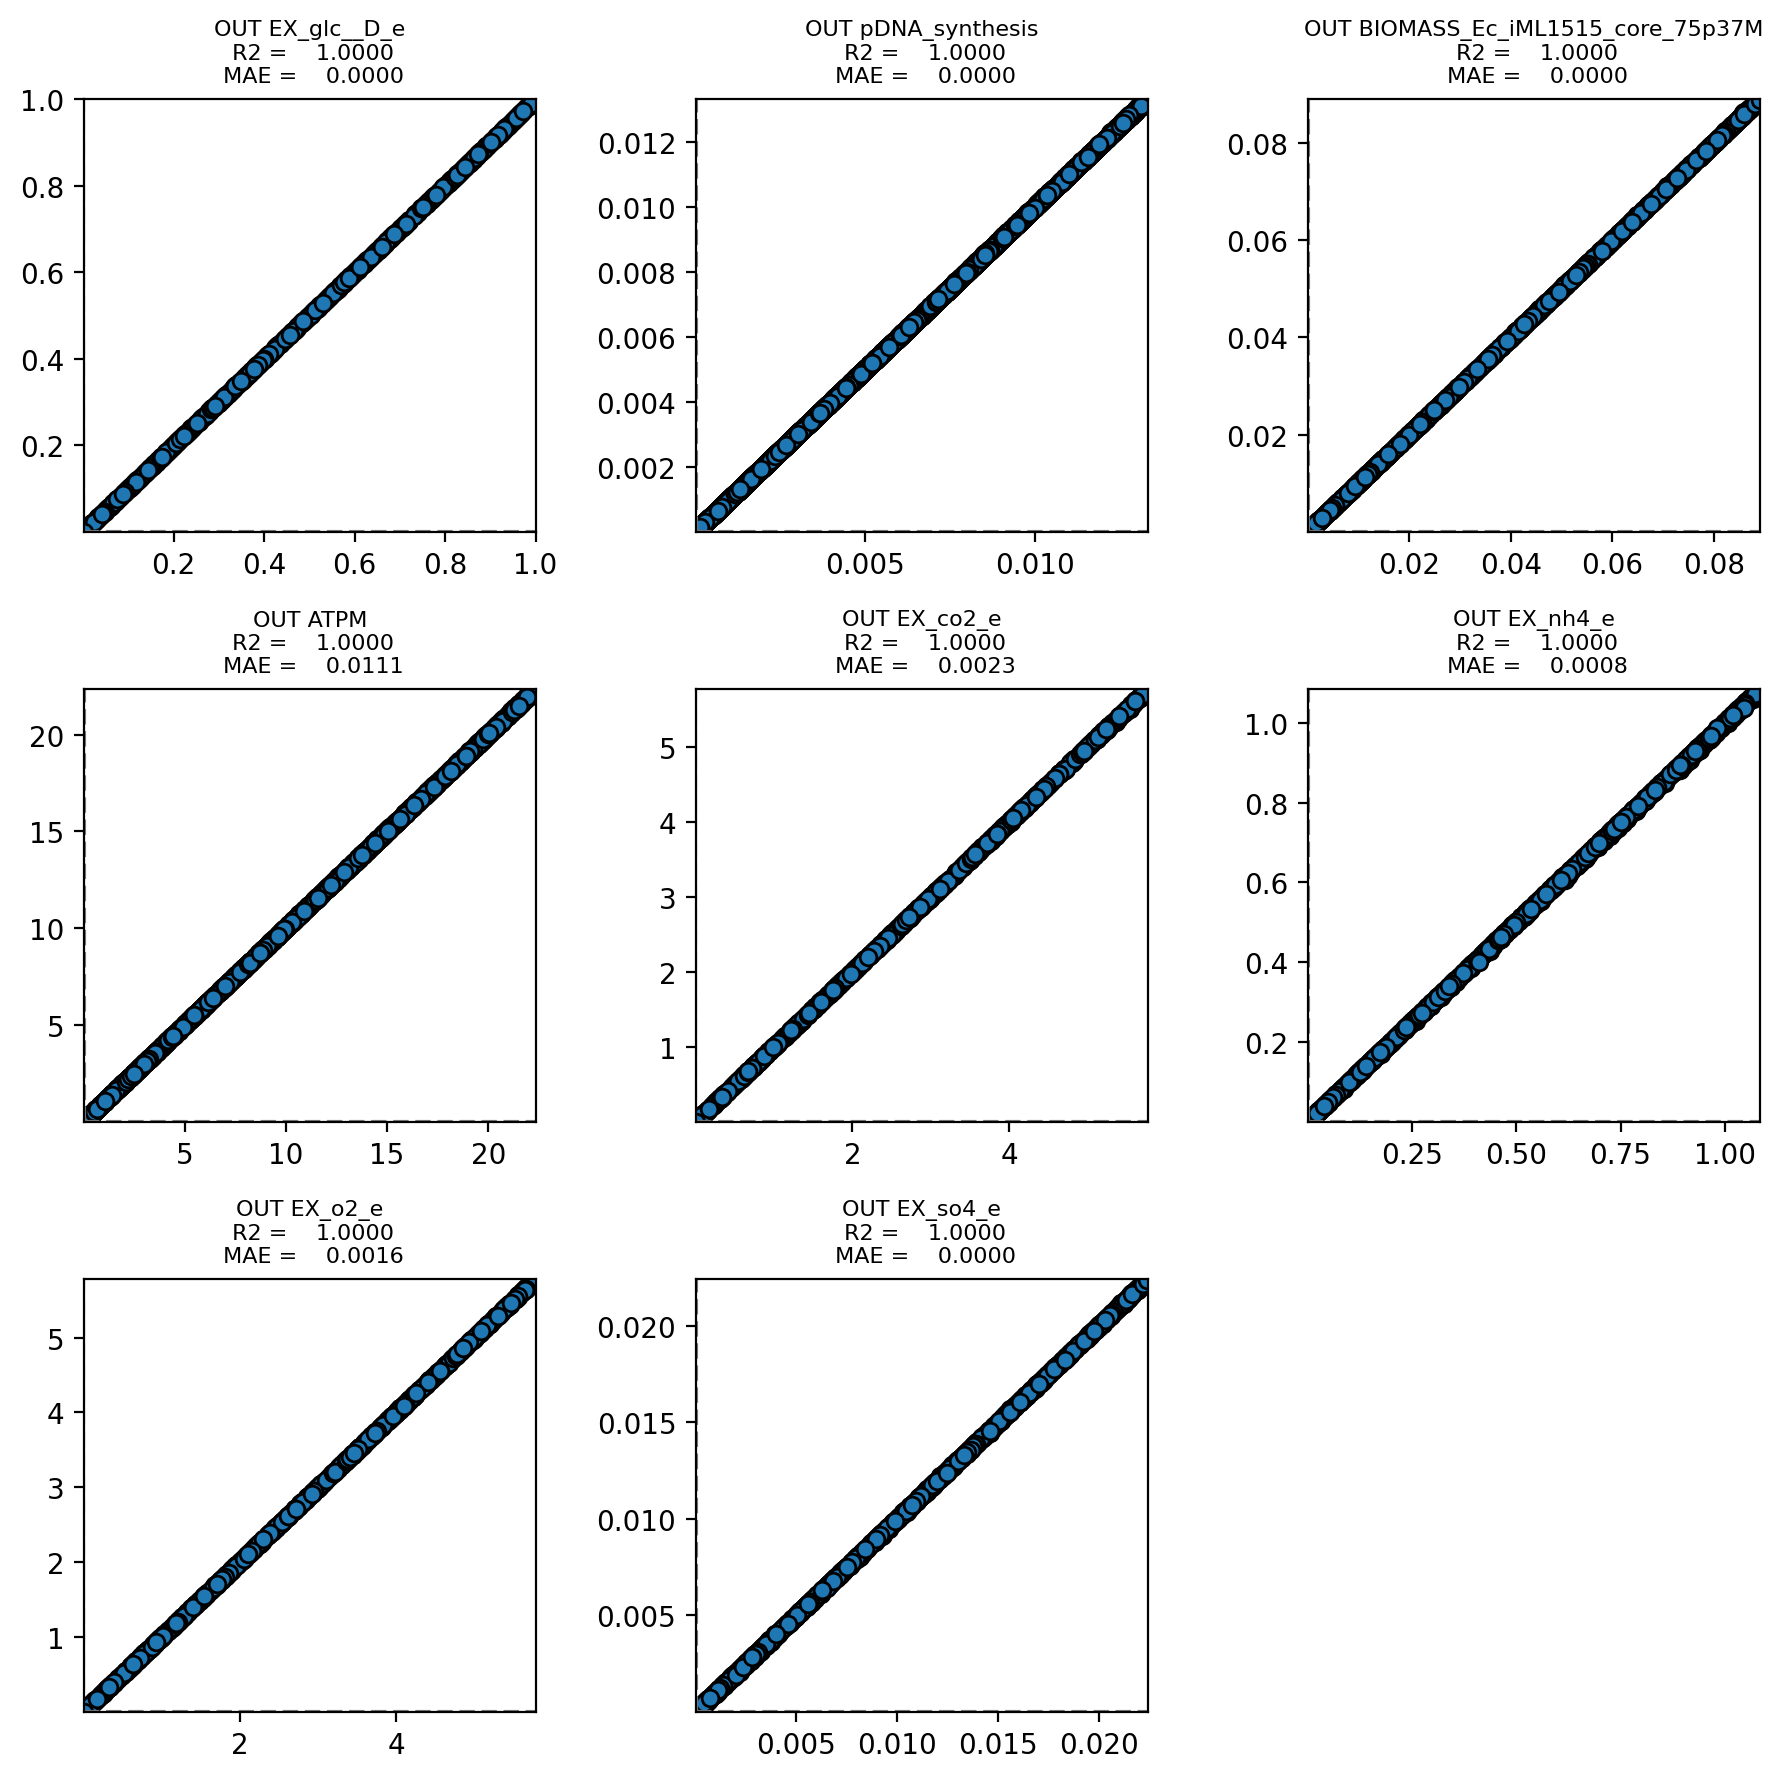

In [17]:
Y_data = y_data
Y_pred = y_pred

Y_data = SCLs[1].unscale(y_data)
Y_pred = SCLs[1].unscale(y_pred)

lowest_n_percent = 100
lowest_n_percent = 5
n = 0
n_cols = 3
# COL_out = ['BIOMASS_Ec_iJO1366_core_53p95M']
n_rows = (len(COL_out))//n_cols+1
plt.figure(dpi=200,figsize=(n_cols*3,n_rows*3))

print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")
for i, name in enumerate(COL_out):
    # find the lowest_n_percent of the data
    _max = Y_data[:,i].max()
    _min = Y_data[:,i].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = Y_pred[:,i] <= _new_max


    n += 1
    ax = plt.subplot(n_rows,n_cols,n)
    tmp_r2 = UF.R2(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    tmp_mae= UF.MAE(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    print(f"{name:30} {tmp_r2:9.4f} {tmp_mae:9.4f}")
    plt.title(f"OUT {name}\n R2 = {tmp_r2:9.4f}\n MAE = {tmp_mae:9.4f}",fontsize=8)
    plt.scatter(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i],edgecolor="k")
    UF.diag(ax)
    ax.axhline(0,color="grey",linestyle="--")
    ax.axvline(0,color="grey",linestyle="--")
    ax.set_xlim(_min,_new_max)
    ax.set_ylim(_min,_new_max)
plt.tight_layout()
plt.show()

# Figure for Manuscript

In [8]:
def general_predictor(x_data):
    qG = x_data[:,0]
    n_X = x_data[:,1]
    n_P = x_data[:,2]
    n_M = x_data[:,3]
    qX = qG * 2.095925756666534*n_X /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qP = qG * 1.5774883284049748*n_P /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qM = qG * 1.9885886903097858*n_M /(1.10909581775274*n_X + 0.06282378505932679*n_P + 0.856382771607087*n_M) 
    qCO2 = qG * (1.2082933347251283*n_X + 0.03140682552481298*n_P + 2.4389345018027253*n_M) /(2.0273005373419446*n_X + 0.11774348504170798*n_P + 1.5547353239688702*n_M) 
    qNH4 = qG * (1.9515541853597302*n_X + 0.2147452343087246*n_P + -0.0007234803861126038*n_M) /(1.1874825647695029*n_X + 0.06552739969547203*n_P + 0.911539718451724*n_M) 
    qO2 = qG * (0.9545539690035202*n_X + 0.047285966317114195*n_P + 2.0881011826979528*n_M) /(1.7127767420491968*n_X + 0.09842279611123259*n_P + 1.3054046578313026*n_M) 
    qSO4 = qG * (5.876098016267782*n_X + 0.000509871455802084*n_P + -0.0015773984660723997*n_M) /(3.111874219100181*n_X + 0.1769442128559814*n_P + 2.3968877820508285*n_M)
    return jnp.stack([qG,qP,qX,qM,qCO2,qNH4,qO2,qSO4],axis=1)

In [9]:
# validation data set

x_data, y_data = valid_
y_pred = general_predictor(x_data)

Lowest 100% of the data
name                              tmp_r2   tmp_mae
pDNA_synthesis                    1.0000    0.0004
BIOMASS_Ec_iML1515_core_75p37M    1.0000    0.0006
ATPM                              1.0000    0.0001
EX_so4_e                          1.0000    0.0006
Size: (2100, 1800) New Size: (np.int64(124), np.int64(60), np.int64(1967), np.int64(1667))


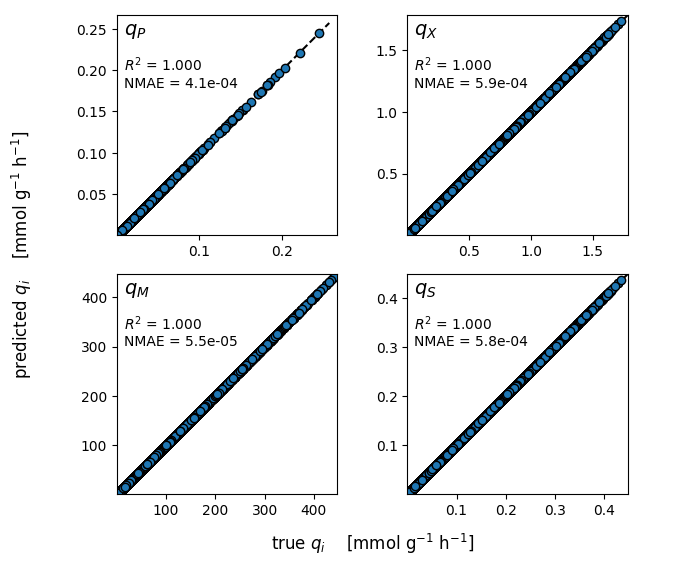

remote: Updating references: 100% (1/1)           
To https://git.overleaf.com/688f5daf4e30e6d98498e7b8
   5ed3db5..55a0fb1  master -> master


Already up to date.
[master 55a0fb1] slim_surrogate_fba_performance.png
 1 file changed, 0 insertions(+), 0 deletions(-)


In [9]:
importlib.reload(UF)

Y_data = y_data
Y_pred = y_pred

Y_data = SCLs[1].unscale(y_data)
Y_pred = SCLs[1].unscale(y_pred)

lowest_n_percent = 100 # plot all data
n = 0
n_cols = 2
# COL_out = ['BIOMASS_Ec_iJO1366_core_53p95M']
n_rows = 2
fig = plt.figure(dpi=100,figsize=(7,6))
# Create invisible subplot.
ax0 = fig.add_subplot(111, frame_on=False)
ax0.tick_params(labelcolor="none", top=False, bottom=False, left=False, right=False)
ax0.grid(False)
# Set the centered xlabel on invisible subplot.
ax0.set_xlabel(r'true $q_i\quad$ [mmol g$^{-1}$ h$^{-1}]$', labelpad=10, fontsize=12)
ax0.set_ylabel(r'predicted $q_i\quad$ [mmol g$^{-1}$ h$^{-1}]$', labelpad=15, fontsize=12)
print(f"Lowest {lowest_n_percent}% of the data")
print(f"{'name':30} {'tmp_r2':>9} {'tmp_mae':>9}")
relevant_indices = [1,2,3,7]
fancynames = [r"$q_P$",r"$q_X$",r"$q_M$",r"$q_S$"]

axes = []
for i, name, fancyname in zip(relevant_indices,COL_out[relevant_indices],fancynames):
# for i, name in enumerate(COL_out):
    # print(i,name)
    # find the lowest_n_percent of the data
    _max = Y_data[:,i].max()
    _min = Y_data[:,i].min()
    _range = _max - _min
    _new_max = _min + (_range * (lowest_n_percent / 100))
    _new_max_mask = Y_pred[:,i] <= _new_max


    n += 1
    ax = plt.subplot(n_rows,n_cols,n,box_aspect=1)
    tmp_r2 = UF.R2(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    tmp_mae= UF.NMAE(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i])
    print(f"{name:30} {tmp_r2:9.4f} {tmp_mae:9.4f}")
    # plt.title(f"{fancyname}")
    text = "\n\n"+rf"$R^2$ = {tmp_r2:5.3f}"+"\n"+rf"NMAE = {tmp_mae:5.1e}"
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, text, transform=ax.transAxes + trans,
    fontsize=10, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))


    plt.scatter(Y_data[_new_max_mask,i],Y_pred[_new_max_mask,i],edgecolor="k")
    UF.diag(ax)
    # ax.axhline(0,color="grey",linestyle="--")
    # ax.axvline(0,color="grey",linestyle="--")
    ax.set_xlim(_min,_new_max)
    ax.set_ylim(_min,_new_max)
    axes.append(ax)

import matplotlib.transforms as mtransforms
for name, ax in zip(fancynames,axes):
    trans = mtransforms.ScaledTranslation(5/72, -5/72, fig.dpi_scale_trans)
    ax.text(0.0, 1.0, name, transform=ax.transAxes + trans,
    fontsize=14, verticalalignment='top', fontfamily='sans',
    bbox=dict(facecolor='none', edgecolor='none', pad=3.0))
plt.tight_layout()

save_trim_push(git_path,"slim_surrogate_fba_performance.png",dpi=300)
plt.show()

In [16]:
i = 7
print(SCLs[1].avg[i], SCLs[1].col[ i])

0.12089817 EX_so4_e


In [19]:
# Scaling of the values
scl = [
    [1],               # qG
    [0.48009762/10 ],  # qX
    [0.01275762/10 ],  # qP
    [101.202324/10 ],  # qM
    [0.12089817/10 ],  # qS
]
scl = np.array(scl).flatten()

In [20]:
arr = np.array([[1.10909581775274, 0.06282378505932679, 0.856382771607087, 1.10909581775274, 0.06282378505932679, 0.856382771607087],
                [2.0959257566665340,0.0000000000000000, 0.0000000000000000,1.10909581775274, 0.06282378505932679, 0.856382771607087,],
                [0.0000000000000000,1.5774883284049748, 0.0000000000000000,1.10909581775274, 0.06282378505932679, 0.856382771607087,],
                [0.0000000000000000,0.0000000000000000, 1.9885886903097858,1.10909581775274, 0.06282378505932679, 0.856382771607087,],
                [5.8760980162677820,0.0005098714558021, -0.001577398466072,3.11187421910018, 0.17694421285598140, 2.396887782050829],])

In [21]:
sclarr = np.zeros_like(arr)

for i in range(arr.shape[0]):
    sclarr[i,:3] = arr[i,:3]*scl[i]
    sclarr[i,3:] = arr[i,3:]
    # break

In [22]:
 import pandas as pd
tab = pd.DataFrame(sclarr,columns=['$Y_X$','$Y_P$','$Y_M$','$W_X$','$W_P$','$W_M$',],index=['$q_G$','$q_X$','$q_P$','$q_M$','$q_S$',])
print(tab.to_latex(float_format="%.4f"))

\begin{tabular}{lrrrrrr}
\toprule
 & $Y_X$ & $Y_P$ & $Y_M$ & $W_X$ & $W_P$ & $W_M$ \\
\midrule
$q_G$ & 1.1091 & 0.0628 & 0.8564 & 1.1091 & 0.0628 & 0.8564 \\
$q_X$ & 0.1006 & 0.0000 & 0.0000 & 1.1091 & 0.0628 & 0.8564 \\
$q_P$ & 0.0000 & 0.0020 & 0.0000 & 1.1091 & 0.0628 & 0.8564 \\
$q_M$ & 0.0000 & 0.0000 & 20.1250 & 1.1091 & 0.0628 & 0.8564 \\
$q_S$ & 0.0710 & 0.0000 & -0.0000 & 3.1119 & 0.1769 & 2.3969 \\
\bottomrule
\end{tabular}

